# 01. Sandbox Notebook

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import sys
sys.path.append("../")

# from PlanetaryCA import PlanetaryCA

In [2]:
import pygame, os, json
from torch.cuda import empty_cache, reset_max_memory_allocated
from importlib.resources import files

from pyca.interface import Camera
from pyca.automata.models import *
from pyca.interface import launch_video, add_frame, print_screen
from pyca.interface.text import TextBlock, DropdownMenu, InputField, render_text_blocks

pygame 2.6.1 (SDL 2.28.4, Python 3.13.3)
Hello from the pygame community. https://www.pygame.org/contribute.html


## 01.A. First CA

In [828]:
from pyca import Automaton
from matplotlib.colors import hsv_to_rgb, to_rgb, to_rgba
import networkx as nx
from sklearn.metrics.pairwise import euclidean_distances

class PlanetaryCA(Automaton):
    def __init__(self, size,
                 n_states: int = 2,
                 n_active: int = 4,
                 dt: float = 1,
                 d_thresh: float = 1,
                 r0: float = 2,
                 seed: float = None,
                 bbox_scale: float = 2,
                 ca_time: int = 100,
                 bouncing: bool = False,
                 viscosity: float = 0.99,
                 damping_factor: float = 0.2,
                 mass_max: int = 10,
                 growth: float = 1.0,
                 k_attract: float = 1.0,
                 k_repel: float = 1.0,
                 wind: float = 10,
                 device: str = 'cpu'):
        super().__init__(size)
        
        self.device=device

        if seed is not None:
            torch.manual_seed(seed)

        # Plotting parameters
        self.el_size = 200
        # self.scale = scale
        self.radius = 4

        self.box_size = torch.tensor([bbox_scale*self.h, bbox_scale*self.w], dtype=torch.float32)
        self.scale = self.box_size/bbox_scale

        # CA Parameters
        self.n_states = n_states
        self.n_active = n_active
        self.state_t = torch.zeros(self.h * self.w, dtype=torch.float32)
        self.mass_max = mass_max
        
        # Kinetics
        self.d_thresh = d_thresh
        self.r0 = r0
        self.damping_factor = damping_factor
        self.k_attract = k_attract
        self.k_repel = k_repel
        self.viscosity = viscosity
        self.ca_time = ca_time
        self.dt = dt
        self.bouncing = bouncing
        self.growth = torch.tensor(growth)

        self.wind = wind
        self._new_world()
        
        self._new_kinetics()

        self._gen_colors()


    def _new_kinetics(self):
        """
        Generates initial kinetics (initialization).
        """
        # self.positions = torch.stack(torch.meshgrid(torch.arange(self.h),torch.arange(self.w),indexing='ij'),
        #                              dim=-1).to(self.device).float() # (H,W,2), positions[x,y] = (x,y)
        # self.positions += torch.tensor([self.h/2+0.5, self.w/2+0.5])
        self.positions = torch.rand(size=(self.h, self.w, 2))*self.scale + torch.tensor([self.h/2+1, self.w/2+1], dtype=torch.float32, device=self.device)
        self.pos_vec = self.positions.view((-1, 2)).float()

        self.v = torch.zeros((self.h * self.w, 2), dtype=torch.float32) # (H * W, 2), velocity of each cell
        # self.m = 0.5*torch.ones(self.h * self.w, dtype=torch.float32) # (H * W), mass of each cell
        # self.m = torch.ones(self.h * self.w, dtype=torch.float32) # (H * W), mass of each cell
        self.m = torch.ones(self.h * self.w, dtype=torch.float32) * self.mass_max # (H * W), mass of each cell
        # self.m = - (self.world * torch.arange(1, self.n_states+1)).sum(dim=1) + (self.n_states+1)

        self.time = 0


    def _new_world(self):
        """
        Generates a new world (initialization).
        """
        # self.active_cells = torch.multinomial(torch.ones(self.h*self.w), self.n_active*self.n_states, replacement=False)
        self.active_cells = torch.arange(self.h*self.w, dtype=torch.int)
        self.world = torch.zeros((self.h * self.w, self.n_states), dtype=torch.int, device=self.device)
        
        for i in range(self.n_states):
            self.world[self.active_cells[i::self.n_states], i] = 1

        self.graph = nx.grid_2d_graph(self.h, self.w) # Create a grid graph for the automaton

        # self.cst_forces = torch.rand((self.n_states, 2))
        # self.cst_forces /= torch.norm(self.cst_forces, dim=1, keepdim=True)
        
        rand_angle = torch.rand(self.n_states) * 2 * np.pi
        self.cst_forces = torch.stack([torch.cos(rand_angle), torch.sin(rand_angle)], dim=1)
        self.cst_forces = torch.concatenate((torch.zeros((1, 2)), self.cst_forces), dim=0)  # Add a zero force for the inactive state

        self._new_kinetics()
        self._compute_forces()
        
        self.dirac = torch.zeros(self.n_states)
        self.dirac[0] = 1


    def _gen_colors(self, cmap="coolwarm"):
        """
        Generates a colormap for the automaton.
        """

        cmap = plt.get_cmap("coolwarm", 3)
        white_col = torch.tensor(to_rgba(cmap(1)[:3], alpha=0.5))
        
        if self.n_states == 2:
            cmap = plt.get_cmap(cmap, self.n_states + 1)
            coldic = {0: white_col,
                      1: torch.tensor(to_rgba(cmap(0)[:3], alpha=0.5)),
                      2: torch.tensor(to_rgba(cmap(2)[:3], alpha=0.5))}
        elif self.n_states != 2:
            cmap = plt.get_cmap("turbo", self.n_states + 3)
            coldic = {0: white_col}
            coldic.update({i: torch.tensor(to_rgba(cmap(i+1)[:3], alpha=0.5)) for i in range(1, self.n_states+1)})
        else:
            return NotImplementedError('Colors not implemented for n_states other than 2')
        self.color_dict = coldic


    def _get_neighbors(self):
        neighbor_mask = (self.dist < self.d_thresh) & (self.dist > 0)  # exclude self

        neighbors = [np.where(neighbor_mask[i])[0].tolist() for i in range(len(self.pos_vec))]
        return neighbors
    

    def _get_force_signs(self):
        state = (self.world * torch.arange(1, self.n_states+1)).sum(dim=1)

        # Outer comparison matrix
        Si = state[:, None]
        Sj = state[None, :]

        a_mask = (Si == Sj) * (Si * Sj > 0)
        a_mask.fill_diagonal_(False)  # Exclude self-comparison

        r_mask = (Si != Sj)
        r_mask.fill_diagonal_(False)  # Exclude self-comparison

        return a_mask, r_mask


    def _compute_forces(self, softening=1e-2):
        delta = self.pos_vec[:, np.newaxis, :] - self.pos_vec[np.newaxis, :, :]  # (N, N, 2)

        # Minimum image convention for periodic boundaries
        if not self.bouncing:
            delta = (delta + self.box_size / 2) % self.box_size - self.box_size / 2

        # self.dist = np.linalg.norm(delta, axis=2) + softening
        self.dist = torch.norm(delta, dim=2) + softening # (N, N)
        self.dist.fill_diagonal_(1.0)
        # self.dist.fill_diagonal_(torch.inf)

        # TODO: Use f = -6 * tau^6 * (tau^6 / r^6  - 1) / r^7
        m_product = self.m[:, np.newaxis] * self.m[np.newaxis, :]
        m_product *= 10

        # TODO: Threshold forces for distances above a threshold
        unit_vect = delta / self.dist[:, :, np.newaxis]
        unit_vect[self.dist == 0] = 0

        attract_mask, repel_mask = self._get_force_signs()

        # Ensure repel mask includes distances below r0
        repel_mask = torch.logical_or(repel_mask, self.dist < self.r0)

        # Initialize force strengths
        F_strength = torch.zeros_like(self.dist)

        # Apply conditional force rules
        F_strength[attract_mask] = -self.k_attract * m_product[attract_mask] / self.dist[attract_mask]
        F_strength[repel_mask] = self.k_repel * m_product[repel_mask] / self.dist[repel_mask]

        F_vec = F_strength[:, :, np.newaxis] * unit_vect
        # return F_strength, F_vec, delta
        total_force = torch.sum(F_vec, axis=1)
        return total_force
    

    def _compute_forces_lj(self, epsilon=1.0, sigma=1.0, r_cutoff=5.0, max_force=10, softening=1e-2):
        """
        Computes Lennard-Jones forces between 2D particles.

        Parameters:
        - positions: (N, 2) array of 2D coordinates
        - epsilon: depth of the potential well
        - sigma: characteristic distance
        - r_cutoff: cutoff distance for performance (optional)

        Returns:
        - forces: (N, 2) array of resulting forces on each particle
        """
        forces = np.zeros_like(self.pos_vec)

        # Pairwise displacements
        delta = self.pos_vec[:, np.newaxis, :] - self.pos_vec[np.newaxis, :, :]  # (N, N, 2)

        # Minimum image convention for periodic boundaries
        if not self.bouncing:
            delta = (delta + self.box_size / 2) % self.box_size - self.box_size / 2

        # self.dist = np.linalg.norm(delta, axis=2) + softening
        self.dist = torch.norm(delta, dim=2) + softening # (N, N)
        self.dist.fill_diagonal_(1.0)

        # Apply cutoff
        mask = (self.dist > 0) & (self.dist < r_cutoff)

        # Compute pairwise Lennard-Jones force magnitudes
        inv_r6 = (sigma / self.dist[mask]) ** 6
        inv_r12 = inv_r6 ** 2
        force_mag = 24 * epsilon * (2 * inv_r12 - inv_r6) / self.dist[mask]  # shape (M,)

        # Normalize displacement vectors
        delta_unit = delta[mask] / self.dist[mask][:, None]  # (M, 2)

        # Apply force directions
        # force_vectors = force_mag[:, None] * delta_unit  # (M, 2)
        force_vectors = np.clip(force_mag, -max_force, +max_force)[:, None] * delta_unit  # (M, 2)
        force_vectors[(self.dist < self.r0).view(-1)] *= 1

        # Build full force array by scattering
        i_indices, j_indices = np.where(mask)
        np.add.at(forces, i_indices, -force_vectors)  # F_ij = -F_ji
        np.add.at(forces, j_indices, +force_vectors)

        return forces


    def kinetic_step(self, softening=1e-2):
        forces = self._compute_forces()

        forces += self.wind * self.cst_forces[(self.world * torch.arange(1, self.n_states+1)).sum(dim=1)]  # Add constant forces based on state

        # forces = self._compute_forces_lj(sigma=2, max_force=1000, r_cutoff=1e5, softening=softening)
        acceleration = forces / (self.m[:, np.newaxis] + softening)
        self.v += acceleration * self.dt
        # add damping
        self.v *= self.viscosity

        self.pos_vec += self.v * self.dt

        if self.bouncing:
            # Bouncing walls
            for dim in [0, 1]:  # x and y
                mask_low = self.pos_vec[:, dim] < 0
                mask_high = self.pos_vec[:, dim] > self.box_size[dim]

                # Reflect position
                self.pos_vec[mask_low, dim] = 0
                self.pos_vec[mask_high, dim] = 2*self.box_size[dim] - self.pos_vec[mask_high, dim]

                # Reverse velocity on bounce
                self.v[mask_low | mask_high, dim] *= -1
        else:
            # Wrap positions back into the box
            self.pos_vec = self.pos_vec % self.box_size

        self.positions = self.pos_vec.view((self.w, self.h, 2))

        self.time += 1
    

    def ca_step(self):
        new_world = torch.zeros_like(self.world) # (H * W, 2), copy of the world
        neighbors = self._get_neighbors()

        for n_i, neigh in enumerate(neighbors):
            neigh_count = self.world[neigh].sum(axis=0)

            max_state = neigh_count.argmax().item()

            if neigh_count.sum() != 0:
                new_world[n_i] = torch.roll(self.dirac, max_state)

            if torch.count_nonzero(neigh_count) == 1 and neigh_count[max_state] > 3:
                self.m[n_i] -= 1*self.growth

            # if neigh_count[max_state] > 3:
            #     new_world[n_i] = 0
            #     self.m[n_i] = 1

        new_world[self.m <= 0, :] = 0 # Reset cells with too much mass
        self.m[self.m <= 0] = self.mass_max # Reset cells with too much mass

        # self.state_t += ((new_world * torch.arange(1, self.n_states+1)).sum(dim=1) == (self.world * torch.arange(1, self.n_states+1)).sum(dim=1)).int()

        # new_world[self.state_t > 10] = 0 # Reset cells which have not changed for a long time

        # self.m = - (new_world * torch.arange(1, self.n_states+1)).sum(dim=1) + (self.n_states+1)

        return new_world


    def step(self):
        """
            Makes one step of the automaton
        """
        self.kinetic_step()

        if self.time > self.ca_time:
            self.time = 0
            
            self.world = self.ca_step()

        # self.m[self.world.sum(dim=1) > 0] = 1

    def step_old(self):
        """
            Makes one step of the automaton
        """
        new_world = torch.zeros_like(self.world) # (H,W,3), copy of the world

        # n_l = self.world.roll(-1, dims=0)
        # n_r = self.world.roll(1, dims=0)
        
        # n_a = self.world.roll(-1, dims=1)
        # n_b = self.world.roll(1, dims=1)
        
        for y in range(self.h):
            for x in range(self.w) : # loop over all cells
                sum_neigh1 = 0 # initialize the neighbour sum
                sum_neigh2 = 0
                for dx,dy in [(1,1),(1,0),(1,-1),(0,1),(0,-1),(-1,-1),(-1,0),(-1,1)]: # Iterate over Neighbors
                # for dx,dy in [(1,0),(0,1),(0,-1),(-1,0)]: # Iterate over Neighbors (4)
                    sum_neigh1 += self.world[(y+dy)%self.h,(x+dx)%self.w, 0] == 1 # State 1
                    sum_neigh2 += self.world[(y+dy)%self.h,(x+dx)%self.w, 1] == 1 # State 2
                if self.world[y,x].sum() == 0 : # Current cell is dead
                    if(sum_neigh1 > sum_neigh2): # Condition for it to become S1
                        new_world[y,x, 0] = 1
                    elif(sum_neigh1 < sum_neigh2): # Condition for it to stay S0
                        new_world[y,x, 1] = 1
                elif self.world[y,x, 0] == 1: # Current cell is S1
                    if(sum_neigh2 > sum_neigh1 + 1):
                        new_world[y,x, 1] = 1
                    else:
                        new_world[y,x, 0] = 1
                else:
                    if(sum_neigh1 > sum_neigh2 + 1):
                        new_world[y,x, 0] = 1
                    else:
                        new_world[y,x, 1] = 1

        self.time+=1

        self.world = new_world


    def reset(self):
        """
            Resets the automaton to the initial state.
        """
        self._worldmap = torch.zeros_like(self._worldmap)
        self.time=0

        self._new_world()

    
    def process_event(self, event, camera=None):
        """
        DEL -> resets the automaton
        UP -> increase the number of starting cells by 1 (max 20)
        DOWN -> decrease the number of starting cells by 1 (min 2)
        """
        if(event.type == pygame.KEYDOWN):
            if event.key == pygame.K_BACKSPACE or event.key == pygame.K_DELETE:
                self.reset() 
                self.draw()

            if event.key == pygame.K_UP:
                self.n_active = torch.min(torch.tensor([self.n_active+1, 20]))
            if event.key == pygame.K_DOWN:
                self.n_active = torch.max(torch.tensor([self.n_active-1, 2]))


    def draw(self):
        """
            Draws the current state of the automaton, using arbitrary coloration which looks nice.
        """
        # self._worldmap=self.get_color_world() # (3,H,W)
        # self._worldmap = self.world.view(-1, self.n_states)
        # self._worldmap = self.world * torch.arange(1, self.n_states+1)
        pass


    @property
    def worldsurface(self):

        surf = pygame.Surface((self.el_size*self.w, self.el_size*self.w))
        surf.fill("black")
        
        # x_pos, y_pos = self.positions.view(-1, 2).t().numpy().astype(int)
        x_pos, y_pos = (self.positions.view(-1, 2) * self.scale).t().int()

        cell_states = (self.world * torch.arange(1, self.n_states+1)).sum(dim=1)

        n_wrap_dist = torch.norm(self.pos_vec[:, None, :] - self.pos_vec[None, :, :], dim=2)
        a_mat = (n_wrap_dist < self.d_thresh).int().numpy()
        np.fill_diagonal(a_mat, 0)

        edges = nx.Graph(a_mat).edges()
        
        for e in edges:
            # pygame.draw.line(surface, color, start_pos, end_pos, width=1)
            pygame.draw.line(surf, "gray", (x_pos[e[0]], y_pos[e[0]]), (x_pos[e[1]], y_pos[e[1]]), width=2)

        for x, y, state, mass in zip(x_pos, y_pos, cell_states, self.m):
            pygame.draw.circle(surf, 255*self.color_dict[state.item()].numpy(), (x, y), self.radius+mass.int())
        
        return surf
 
    # @property
    # def worldmap(self):
    #     return self._worldmap.view(-1, self.n_states)
 

In [829]:
planca = PlanetaryCA((6, 6), n_states=3, seed=240896,
                     n_active=4, d_thresh=2, device='cpu')

planca.worldsurface

<Surface(1200x1200x32 SW)>

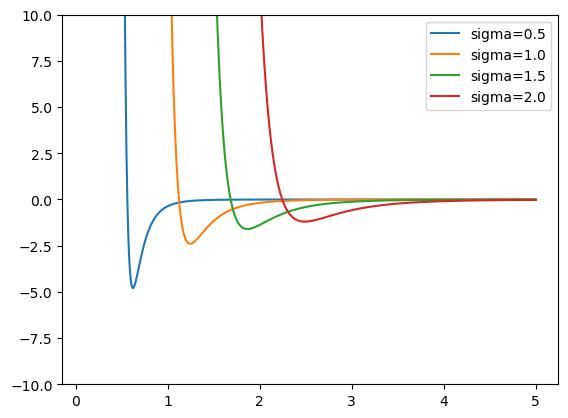

In [830]:
def lennard_force(r, sigma=1):
    return 48*(sigma**12 /r**13 - 0.5 * sigma**6 / r**7)


x = torch.linspace(0.1, 5, 1000)

for sigma in np.arange(0.5, 2.5, 0.5):
    plt.plot(x, lennard_force(x, sigma), label=f'sigma={sigma}')

plt.ylim(-10, 10)
plt.legend()

## Run in notebook ?

In [831]:
# === Pygame Visualization ===
def run_simulation(screen_size=(800, 800), graph_size=(6, 6), n_states=2, fps=60, **kwargs):
    pygame.init()
    screen = pygame.display.set_mode(screen_size)

    pygame.display.set_caption("Planetary Cellular Automata Simulation")
    programIcon = pygame.image.load(files('pyca.interface.files').joinpath('icon.png'))
    pygame.display.set_icon(programIcon)
    clock = pygame.time.Clock()

    planca = PlanetaryCA(graph_size, n_states=n_states, n_active=4, device='cpu', **kwargs)
    
    scale = torch.tensor(screen_size)/planca.box_size

    planca.scale = scale

    running = True
    stopped = True
    while running:
        screen.fill((10, 10, 20))
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

            if event.type == pygame.KEYDOWN :
                if(event.key == pygame.K_SPACE): # Press 'SPACE' to start/stop the automaton
                    stopped=not(stopped)
                if(event.key == pygame.K_q):
                    running=False
                if(event.key == pygame.K_s):
                    planca.step()

            planca.process_event(event) # Process the event in the automaton

        if(not stopped):
            planca.step()

        planca.draw()
        
        world_surface = planca.worldsurface

        screen.blit(world_surface, (1,1))

        pygame.display.flip()
        clock.tick(fps)

    pygame.quit()

In [832]:
run_simulation((600, 600), graph_size=(10, 10), n_states=3, fps=60, dt=0.005, d_thresh=2, r0=5, ca_time=2, seed=220367, k_attract=1, k_repel=2, growth=1, viscosity=0.99, wind=0, bbox_scale=4, mass_max=5)
# run_simulation((600, 600), graph_size=(10, 10), n_states=3, fps=60, dt=0.005, d_thresh=2, r0=1, ca_time=5, k_attract=1, k_repel=5, growth=1, viscosity=0.99, wind=0, bbox_scale=4, mass_max=5)

In [ ]:
if os.name == 'posix':  # Check if OS is Linux/Unix
    print("Setting window position to 0, 0")
    os.environ["SDL_VIDEO_WINDOW_POS"] = "0, 0"

font_path = str(files('pyca.interface.files').joinpath('AldotheApache.ttf'))
std_help = None

with open(str(files('pyca.interface.files').joinpath('std_help.json')), 'r') as f:
    std_help = json.load(f)

def gameloop(screen: tuple[int], world: tuple[int], device: str):
    # Define available automaton classes
    automaton_options = {
        "CA2D":         lambda h, w: CA2D((h,w), b_num='3', s_num='23', random=True, device=device),
        "ElementaryCA": lambda h, w: ElementaryCA((h,w), wolfram_num=90, random=True),
        "Rule110Universality": lambda h, w: Rule110Universality((h,w), wolfram_num=110, random=True),
        "Totalistic1DCA":lambda h, w: TotalisticCA1D((h,w), wolfram_num=1203, r=3, k=3, random=True),
        "LGCA":         lambda h, w: LGCA((h,w), device=device),
        "Gray-Scott":   lambda h, w: GrayScott((h,w), device=device),
        "Belousov-Zhabotinsky": lambda h, w: BelousovZhabotinsky((h,w), device=device),
        "Brusselator":  lambda h, w: Brusselator((h,w), device=device),
        "Falling Sand": lambda h, w: FallingSand((h,w)),
        "Baricelli 2D": lambda h, w: Baricelli2D((h,w), n_species=7, reprod_collision=True, device=device),
        "Baricelli 1D": lambda h, w: Baricelli1D((h,w), n_species=8, reprod_collision=True),
        "MultiLenia":   lambda h, w: MultiLenia((h,w), dt=0.1, num_channels=3, param_path='lenia_cool_params', device=device),
        "Neural CA":    lambda h, w: NCA((h,w), models_folder='saved_models/NCA/', device=device),
        "Von Neumann":  lambda h, w: VonNeumann((h,w),element_size=9, device=device),
        "Planetary":  lambda h, w: PlanetaryCA((h,w), n_states=2),
    }

    
    # Replace the static sW, sH definition with:
    sW, sH = screen

    # Automaton world size 
    W, H = world
    cW, cH = ((W+1)*10, (H+1)*10)
    # Device to run the automaton
    device = device

    fps = 60 # Visualization (target) frames per second
    video_fps = 60 # Video frames per second

    text_size = int(sH/45)
    title_size = int(text_size*1.3)
    font = pygame.font.Font(font_path, size=text_size)
    font_title = pygame.font.Font(font_path, size=title_size)

    programIcon = pygame.image.load(files('pyca.interface.files').joinpath('icon.png'))
    pygame.display.set_icon(programIcon)
    pygame.display.set_caption('PyCA')
    screen = pygame.display.set_mode((sW,sH), flags=pygame.RESIZABLE)
    clock = pygame.time.Clock() 
    running = True
    camera = Camera(cW,cH)
    camera.resize(sW,sH)
    zoom = min(sW/cW,sH/cH)
    camera.zoom = zoom

    # Booleans for the main loop
    stopped=True
    recording=False
    launch_vid=True
    display_help=True
    writer=None

    # Then when initializing the first automaton:
    # initial_automaton = "CA2D"
    initial_automaton = "Planetary"
    auto = automaton_options[initial_automaton](H, W)

    description, help_text = auto.get_help()

    def make_text_blocks(description, help_text, std_help, font, font_title):
        text_blocks = [
            TextBlock(description, "up_sx", (74, 101, 176), font_title),
            TextBlock("\n", "up_sx", (230, 230, 230), font)
        ]
        for section in std_help['sections']:
            text_blocks.append(TextBlock(section["title"], "up_sx", (230, 89, 89), font))
            for command, description in section["commands"].items():
                text_blocks.append(TextBlock(f"{command} -> {description}", "up_sx", (230, 230, 230), font))
            text_blocks.append(TextBlock("\n", "up_sx", (230, 230, 230), font))
        text_blocks.append(TextBlock("Automaton controls", "below_sx", (230, 89, 89), font))
        text_blocks.append(TextBlock(help_text, "below_sx", (230, 230, 230), font))
        return text_blocks

    text_blocks = make_text_blocks(description, help_text, std_help, font, font_title)

    # Update these initial sizes to be relative to screen size
    button_width = int(sW * 0.15)  # 15% of screen width
    button_height = int(sH * 0.05)  # 5% of screen height
    input_width = int(sW * 0.05)   # 5% of screen width
    input_height = int(sH * 0.05)  # 5% of screen height
    margin = int(sH * 0.02)        # 2% of screen height


    dropdown = DropdownMenu(
        screen=screen,
        width=button_width,
        height=button_height,
        font=font,
        options=automaton_options,
        default_option=initial_automaton,
        margin=margin
    )

    # Update input fields with new relative sizes
    w_input = InputField(
        screen=screen,
        width=input_width,
        height=input_height,
        font=font,
        label="Width",
        initial_value=W,
        margin=margin,
        index=0
    )

    h_input = InputField(
        screen=screen,
        width=input_width,
        height=input_height,
        font=font,
        label="Height",
        initial_value=H,
        margin=margin,
        index=1
    )

    fps_input = InputField(
        screen=screen,
        width=input_width,
        height=input_height,
        font=font,
        label="FPS",
        initial_value=fps,
        margin=margin,
        index=2
    )


    while running:

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            
            camera.handle_event(event) # Handle the camera events

            if event.type == pygame.KEYDOWN :
                if(event.key == pygame.K_SPACE): # Press 'SPACE' to start/stop the automaton
                    stopped=not(stopped)
                if(event.key == pygame.K_q):
                    running=False
                if(event.key == pygame.K_r): # Press 'R' to start/stop recording
                    recording = not recording
                    if(not launch_vid and writer is not None):
                        launch_vid=True
                        writer.release()
                if(event.key == pygame.K_p):
                    print_screen(auto.worldsurface)
                if(event.key == pygame.K_s):
                    auto.step()
                if (event.key == pygame.K_h):
                    display_help = not display_help
                if (event.key == pygame.K_c):
                    current_sW, current_sH = screen.get_size()
                    camera = Camera(W,H)
                    camera.resize(current_sW,current_sH)
                    zoom = min(current_sW/W,current_sH/H)
                    camera.zoom = zoom

            if event.type == pygame.VIDEORESIZE:
                # Get current window size and new window size
                old_w, old_h = screen.get_size()
                new_w, new_h = event.w, event.h
                
                # Calculate scale factors
                scale_w = new_w / old_w
                scale_h = new_h / old_h
                
                # Update camera with new screen dimensions and scale position and zoom
                camera.resize(new_w, new_h)
                camera.position.x *= scale_w
                camera.position.y *= scale_h
                camera.zoom *= min(scale_w, scale_h)  # Use minimum scale to preserve aspect ratio
                camera.updateFov()
                
                # Calculate new sizes based on new dimensions
                button_width = int(new_w * 0.15)
                button_height = int(new_h * 0.05)
                input_width = int(new_w * 0.05)
                input_height = int(new_h * 0.05)
                margin = int(new_h * 0.02)
                
                # Update text sizes
                text_size = int(new_h/45)
                title_size = int(text_size*1.5)
                font = pygame.font.Font(font_path, size=text_size)
                font_title = pygame.font.Font(font_path, size=title_size)
                
                # Update UI elements with new sizes and font
                dropdown.resize(button_width, button_height, margin, font)
                w_input.resize(input_width, input_height, margin, font)
                h_input.resize(input_width, input_height, margin, font)
                fps_input.resize(input_width, input_height, margin, font)
                
                # Update text blocks with new font
                text_blocks = make_text_blocks(description, help_text, std_help, font, font_title)
            
            auto.process_event(event,camera) # Process the event in the automaton

            if dropdown.handle_event(event):
                # # Handle automaton change
                auto = automaton_options[dropdown.current_option](H, W)
                # Update help text
                description, help_text = auto.get_help()
                text_blocks = make_text_blocks(description, help_text, std_help, font, font_title)

            if(display_help):
                # Handle input field events
                if w_input.handle_event(event):
                    new_w = w_input.get_value()
                    if new_w and new_w > 0:
                        W = new_w
                        current_sW, current_sH = screen.get_size()
                        # Recreate automaton with new size
                        auto = automaton_options[dropdown.current_option](H, W)
                        camera = Camera(W,H)
                        camera.resize(current_sW,current_sH)
                        zoom = min(current_sW/W,current_sH/H)
                        camera.zoom = zoom

                if h_input.handle_event(event):
                    new_h = h_input.get_value()
                    if new_h and new_h > 0:
                        H = new_h
                        current_sW, current_sH = screen.get_size()
                        # Recreate automaton with new size
                        auto = automaton_options[dropdown.current_option](H, W)
                        camera = Camera(W,H)
                        camera.resize(current_sW,current_sH)
                        zoom = min(current_sW/W,current_sH/H)
                        camera.zoom = zoom

                if fps_input.handle_event(event):
                    new_fps = fps_input.get_value()
                    if new_fps and new_fps > 0:
                        fps = new_fps                    
                        


        if(not stopped):
            auto.step() # step the automaton
        
        auto.draw() # draw the worldstate
        world_surface = auto.worldsurface
        
        # Clear the screen
        screen.fill((0, 0, 0))

        # Draw the scaled surface on the window
        zoomed_surface = camera.apply(world_surface, border=True)
        screen.blit(zoomed_surface, (0,0))

        if (recording):
            if(launch_vid):# If the video is not launched, we create it
                launch_vid = False
                writer = launch_video((H,W), video_fps, 'mp4v')
            add_frame(writer,world_surface) # (in the future, we may add the zoomed frame instead of the full frame)
            pygame.draw.circle(screen, (255,0,0), (sW-10,15), 7)
        
        if (display_help):
            render_text_blocks(screen, [TextBlock(f"FPS: {int(clock.get_fps())}", "up_dx", (255, 89, 89), font)])
            render_text_blocks(screen, text_blocks)

        # Draw dropdown (before pygame.display.flip())
        dropdown.draw(screen, display_text=display_help)

        # Draw input fields
        if(display_help):
            w_input.draw()
            h_input.draw()
            fps_input.draw()
        # Update the screen
        pygame.display.flip()

        clock.tick(fps)  # limits FPS to 60

    pygame.quit()

In [ ]:
pygame.init()

gameloop((1280, 720), (10, 10), device='cpu')

In [8]:
import pygame
import numpy as np

# === Physics Simulator ===
class NBodySimulator:
    def __init__(self, xy_init, v_init, m_vec, box_size, dt=0.1):
        self.xy = xy_init.copy()
        self.v = v_init.copy()
        self.m = m_vec.copy()
        self.dt = dt
        self.N = len(m_vec)
        self.box_size = np.array(box_size)

    def compute_forces(self, softening=1e-2):
        delta = self.xy[:, np.newaxis, :] - self.xy[np.newaxis, :, :]  # (N, N, 2)
        dist = np.linalg.norm(delta, axis=2) + softening               # (N, N)
        np.fill_diagonal(dist, 1.0)  # Avoid self-force

        inv_dist = 1.0 / dist
        m_product = self.m[:, np.newaxis] * self.m[np.newaxis, :]
        F_strength = m_product * inv_dist  # (N, N)

        dir_normalized = delta / dist[:, :, np.newaxis]
        dir_normalized[dist == 0] = 0

        F_vec = F_strength[:, :, np.newaxis] * dir_normalized
        total_force = np.sum(F_vec, axis=1)  # (N, 2)
        return total_force

    def step(self):
        forces = self.compute_forces()
        acceleration = forces / self.m[:, np.newaxis]
        self.v += acceleration * self.dt
        self.xy += self.v * self.dt

        self.xy = self.xy % self.box_size


# === Pygame Visualization ===
def run_simulation(N=10, steps=1000, width=800, height=800, scale=40, dt=0.1):
    pygame.init()
    screen = pygame.display.set_mode((width, height))
    pygame.display.set_caption("2D N-Body Simulation")
    clock = pygame.time.Clock()

    box_size = np.array([width // scale, height // scale])

    # Initialize particles
    np.random.seed(42)
    xy = np.random.rand(N, 2) * (width // scale)
    v = np.zeros((N, 2))
    m = np.ones(N)
    colors = [tuple(np.random.randint(100, 255, 3)) for _ in range(N)]

    sim = NBodySimulator(xy, v, m, box_size=box_size, dt=dt)

    running = True
    while running:
        screen.fill((10, 10, 20))
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        sim.step()

        for i in range(N):
            x, y = sim.xy[i] * scale
            pygame.draw.circle(screen, colors[i], (int(x), int(y)), int(10 + m[i]), 0)

        pygame.display.flip()
        clock.tick(60)

    pygame.quit()

In [10]:
run_simulation(N=10, steps=1000, width=800, height=800, scale=40, dt=0.1)

In [11]:
N = 10
width = 1000
height = 1000
scale = 40
dt = 10

box_size = np.array([width // scale, height // scale])

# Initialize particles
np.random.seed(42)
xy = np.random.rand(N, 2) * (width // scale)
v = np.zeros((N, 2))
m = np.ones(N)
colors = [tuple(np.random.randint(100, 255, 3)) for _ in range(N)]

sim = NBodySimulator(xy, v, m, box_size=box_size, dt=dt)
sim.xy.shape

(10, 2)

In [ ]:
planca.positions.shape